# Customer Churn Prediction

## tl;dr

Gradient Boosting produced **0.663 test PR-AUC** and **0.845 ROC-AUC**. At the development-selected threshold it recovered **72.5% of churners**. If outreach is limited to the highest-risk 20% of customers, the model captures **49.7% of churners** with **2.48× lift** over random targeting.

## Context & Methods

The goal is risk ranking for retention outreach. Logistic Regression, Random Forest, and Gradient Boosting are compared using stratified out-of-fold average precision on the development partition. The selected model is evaluated once on an untouched stratified test set.

### Key Assumptions

- `Churn = Yes` identifies a customer who left in the last month.
- The static sample is used for classification, not causal inference.
- A 20% outreach budget is illustrative and should be replaced by real campaign capacity and economics.

In [1]:
from pathlib import Path
import json, os, subprocess, sys
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
env = os.environ.copy()
env['PYTHONPATH'] = str(ROOT / 'src')
subprocess.run([sys.executable, str(ROOT / 'scripts/run_analysis.py')], cwd=ROOT, env=env, check=True, capture_output=True)
summary = json.loads((ROOT / 'reports/summary.json').read_text())
summary

{'rows': 7043,
 'features': 19,
 'overall_churn_rate': 0.2653698707936959,
 'development_rows': 5634,
 'test_rows': 1409,
 'selected_model': 'Gradient Boosting',
 'selection_metric': 'out-of-fold average precision',
 'decision_threshold': 0.33420480017134985,
 'test_pr_auc': 0.6634275293224399,
 'test_roc_auc': 0.8449934123847167,
 'test_precision': 0.5587628865979382,
 'test_recall': 0.7245989304812834,
 'test_f1': 0.6309662398137369,
 'confusion_matrix': {'tn': 821, 'fp': 214, 'fn': 103, 'tp': 271},
 'top_20_percent_targeting': {'customers_targeted': 282,
  'churners_captured': 186,
  'precision': 0.6595744680851063,
  'recall': 0.49732620320855614,
  'lift': 2.484867447946296},
 'caveat': 'This IBM sample describes a fictional telco and is not a production validation population.'}

## Data

The IBM sample contains 7,043 fictional telco customers. Eleven blank `TotalCharges` values are converted to missing and imputed inside each training fold, preventing leakage.

In [2]:
data = pd.read_csv(ROOT / 'data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
pd.DataFrame({'rows': [len(data)], 'columns': [data.shape[1]], 'duplicate_customer_ids': [data.customerID.duplicated().sum()], 'churn_rate': [(data.Churn == 'Yes').mean()]})

,rows,columns,duplicate_customer_ids,churn_rate
0,7043,21,0,0.26537


## Results

### Contract pattern

Month-to-month contracts have the highest observed churn rate. This is an association, not evidence that contract type causes churn.

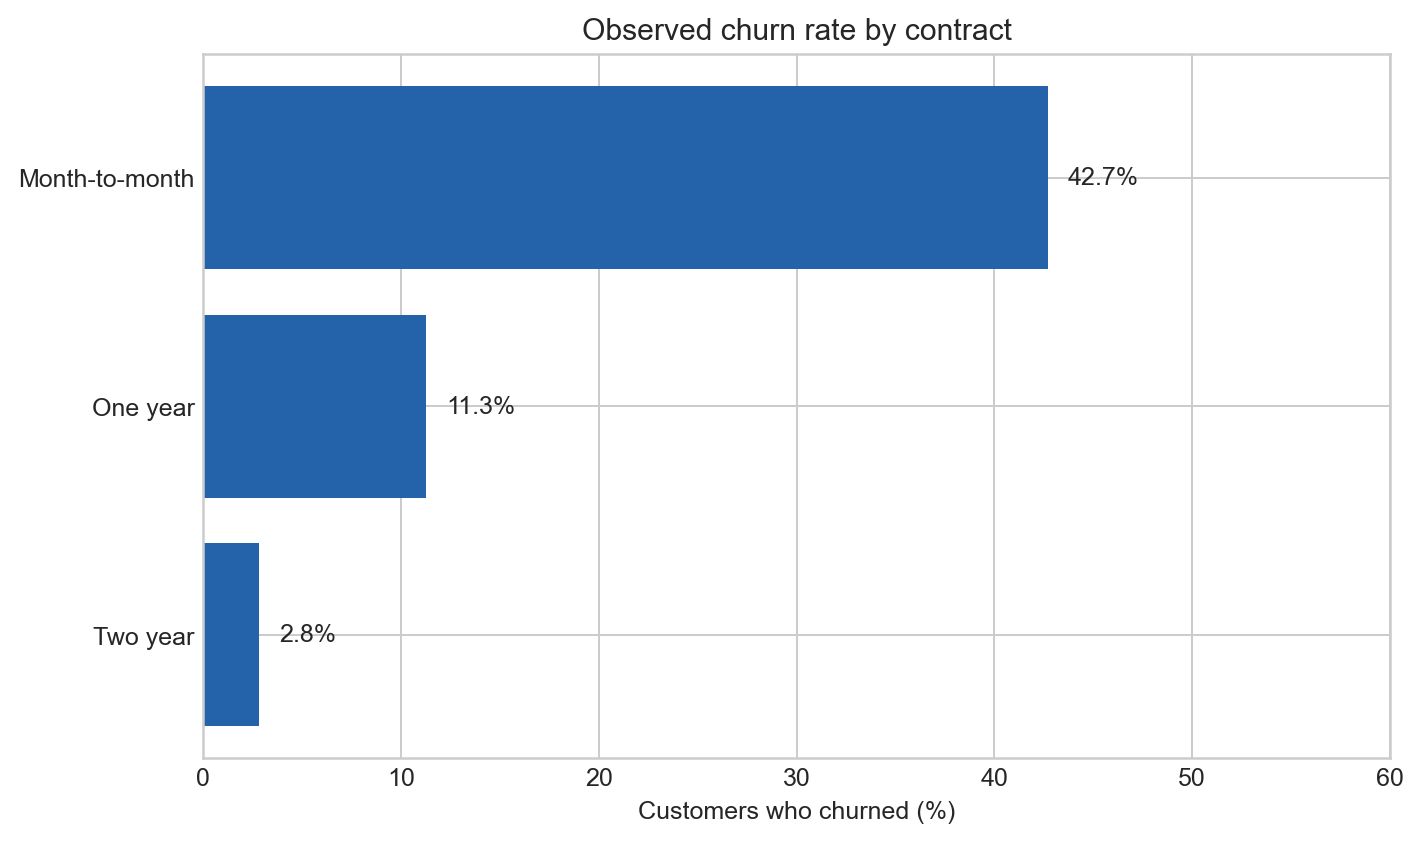

In [3]:
display(Image(filename=ROOT / 'reports/figures/churn_by_contract.png', width=800))

### Model discrimination

Precision–recall curves emphasize performance on the minority churn class; the dashed line is the test-set churn prevalence.

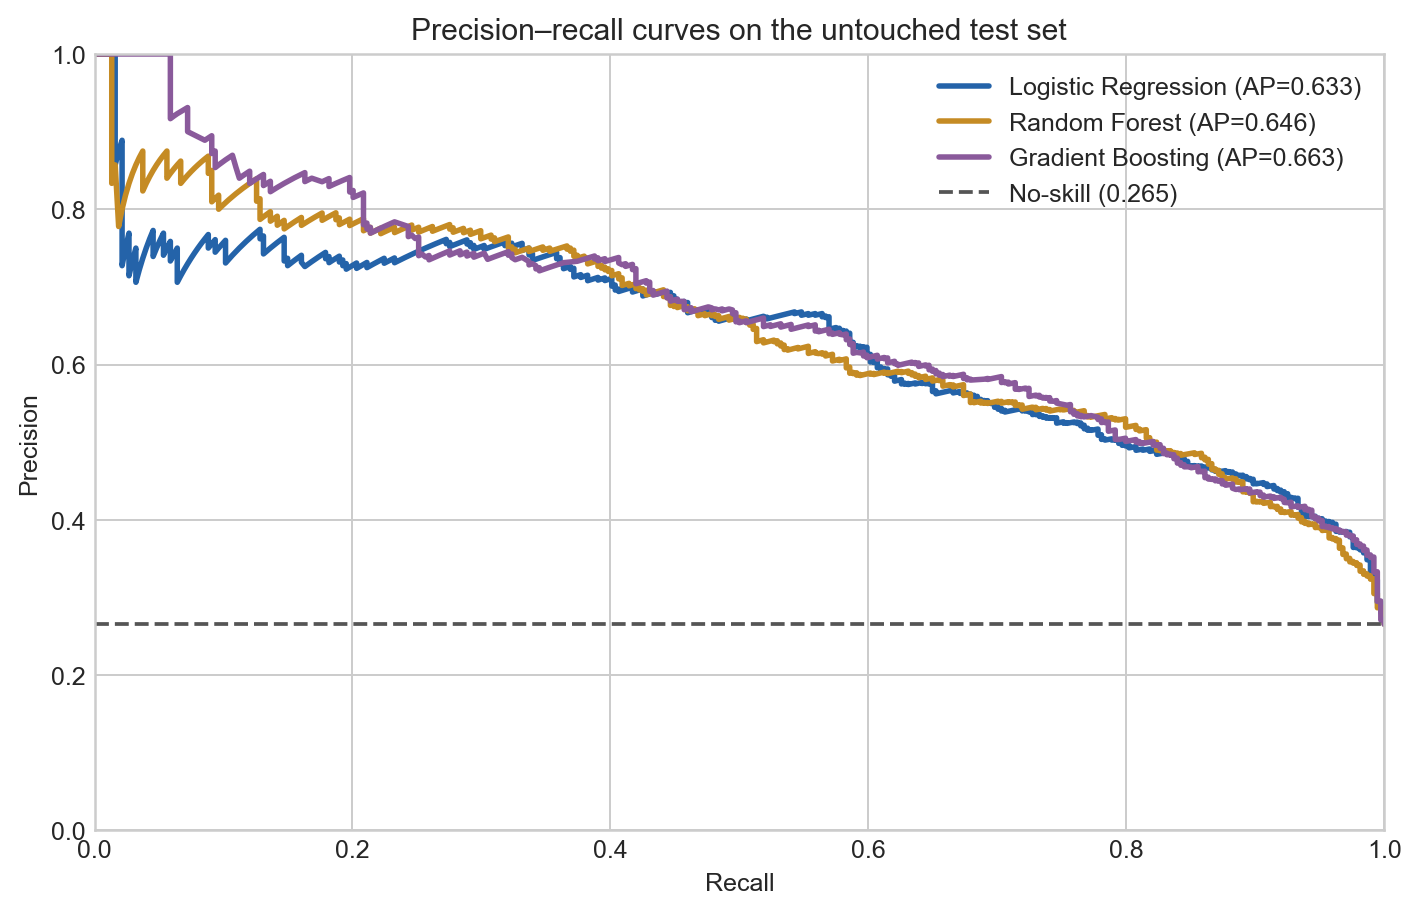

,model,cv_pr_auc,cv_roc_auc,test_pr_auc,test_roc_auc
0,Gradient Boosting,0.665,0.849,0.663,0.845
1,Logistic Regression,0.657,0.845,0.633,0.841
2,Random Forest,0.648,0.842,0.646,0.839


In [4]:
display(Image(filename=ROOT / 'reports/figures/precision_recall_curves.png', width=800))
pd.read_csv(ROOT / 'reports/model_comparison.csv').round(3)

### Model interpretation

Permutation importance measures the decrease in test average precision when a raw input is shuffled. It is predictive importance, not a causal explanation.

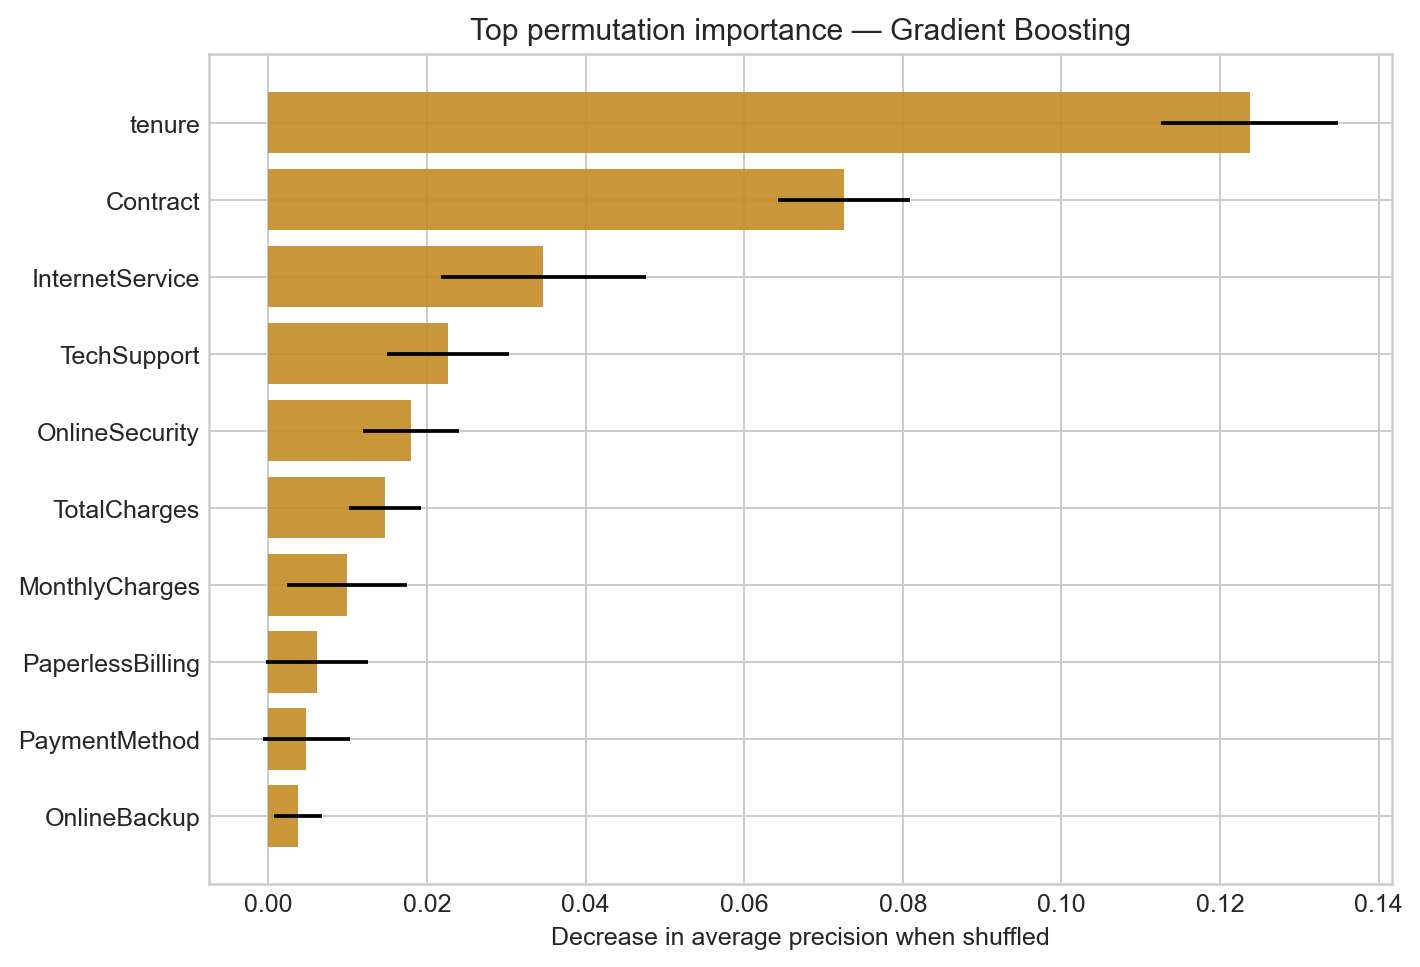

,feature,importance_mean,importance_std
0,tenure,0.1237,0.0112
1,Contract,0.0726,0.0083
2,InternetService,0.0347,0.0129
3,TechSupport,0.0226,0.0077
4,OnlineSecurity,0.0180,0.0060
5,TotalCharges,0.0147,0.0046
6,MonthlyCharges,0.0099,0.0075
7,PaperlessBilling,0.0061,0.0065
8,PaymentMethod,0.0048,0.0055
9,OnlineBackup,0.0037,0.0030


In [5]:
display(Image(filename=ROOT / 'reports/figures/feature_importance.png', width=800))
pd.read_csv(ROOT / 'reports/feature_importance.csv').head(10).round(4)

### Retention targeting

Risk ranking is more actionable than accuracy. The curve shows how much observed churn is captured as outreach capacity expands.

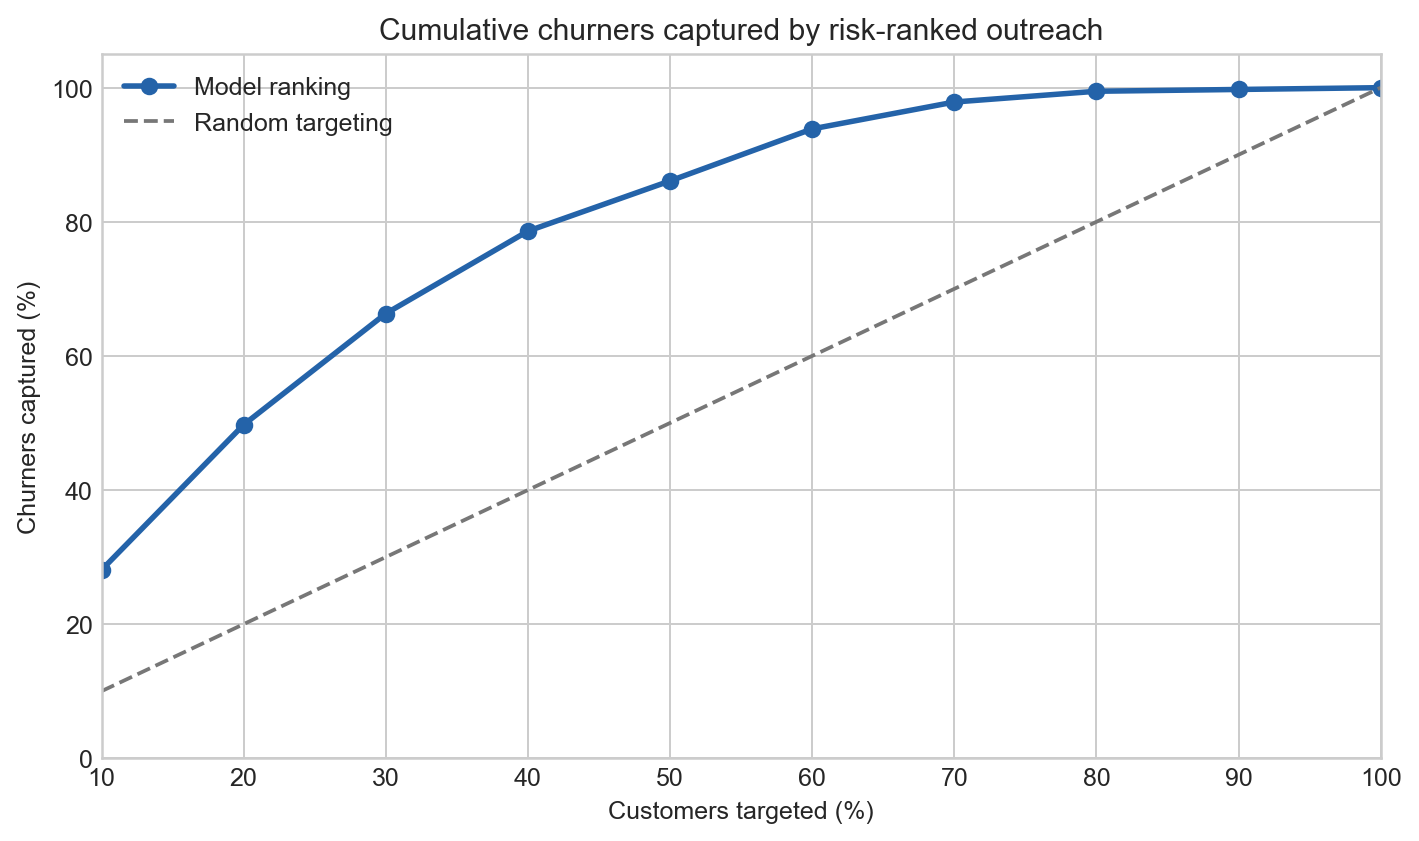

,decile,customers,churners,cumulative_recall
0,1,141,105,0.281
1,2,141,81,0.497
2,3,141,62,0.663
3,4,141,46,0.786
4,5,141,28,0.861
5,6,140,29,0.939
6,7,141,15,0.979
7,8,141,6,0.995
8,9,141,1,0.997
9,10,141,1,1.000


In [6]:
display(Image(filename=ROOT / 'reports/figures/targeting_gains.png', width=800))
pd.read_csv(ROOT / 'reports/targeting_gains.csv').round(3)

## Takeaways

- Use the model to prioritize a human-reviewed retention list, not as an automatic adverse decision.
- A 20% outreach budget captures roughly half of observed churners in the test set.
- Validate on a real, time-ordered customer cohort and measure incremental campaign uplift before deployment.
- Source: [Kaggle — Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn).